In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Salary_Data.csv')

In [ ]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Salary,5
Education Level,3
Years of Experience,3
Age,2
Gender,2
Job Title,2


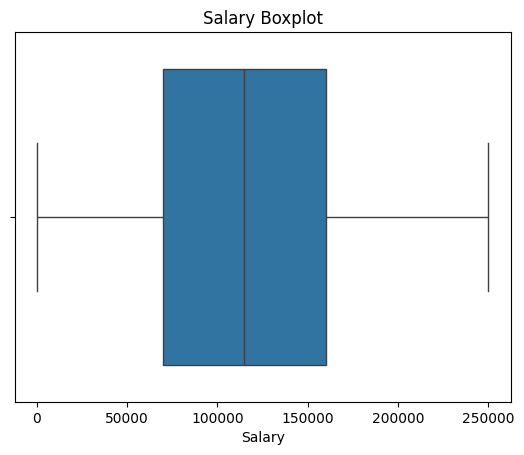

In [ ]:
sns.boxplot(x=df['Salary'], showfliers=True)
plt.title('Salary Boxplot')
plt.show()

In [ ]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < lower) | (df['Salary'] > upper)]

print(len(outliers))

0


In [ ]:
df[df.isnull().any(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN
2011,27.0,Male,NaN,Developer,7.0,100000.0
3136,31.0,Male,Master's Degree,Full Stack Engineer,8.0,NaN
5247,26.0,Female,Bachelor's Degree,Social M,NaN,NaN
6455,36.0,Male,Bachelor's Degree,Sales Director,6.0,NaN


In [ ]:
df = df.dropna(how='all')

In [ ]:
df[df.isnull().any(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
2011,27.0,Male,NaN,Developer,7.0,100000.0
3136,31.0,Male,Master's Degree,Full Stack Engineer,8.0,NaN
5247,26.0,Female,Bachelor's Degree,Social M,NaN,NaN
6455,36.0,Male,Bachelor's Degree,Sales Director,6.0,NaN


In [ ]:
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].mean())
mode_salary = df['Salary'].mode()[0]
df['Salary'] = df['Salary'].fillna(mode_salary)

In [ ]:
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [ ]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [ ]:
df.head()

,Age,Years of Experience,Salary,Gender_Male,Gender_Other,Education Level_Bachelor's Degree,Education Level_High School,Education Level_Master's,Education Level_Master's Degree,Education Level_PhD,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,90000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28.0,3.0,65000.0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45.0,15.0,150000.0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,36.0,7.0,60000.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52.0,20.0,200000.0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


STEP 2: Feature Selection

In [ ]:
x = df.drop('Salary', axis = 1)
y = df['Salary']

In [ ]:
print(x.head())
print(y.head())

    Age  Years of Experience  Gender_Male  Gender_Other  \
0  32.0                  5.0            1             0   
1  28.0                  3.0            0             0   
2  45.0                 15.0            1             0   
3  36.0                  7.0            0             0   
4  52.0                 20.0            1             0   

   Education Level_Bachelor's Degree  Education Level_High School  \
0                                  0                            0   
1                                  0                            0   
2                                  0                            0   
3                                  0                            0   
4                                  0                            0   

   Education Level_Master's  Education Level_Master's Degree  \
0                         0                                0   
1                         1                                0   
2                         0           

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5361, 202)
(1341, 202)
(5361,)
(1341,)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
pred = model.predict(x_test)

print(pred[:10])
print(y_test[:10])

[129583.13100534 182491.18541188  82848.38755954  58883.04346235
  92022.77902087 138910.64651111  99215.44338715  72028.41221578
  75677.0812465  137015.74551605]
5073    120000.0
4464    157000.0
5559     80000.0
6542     40000.0
265      40000.0
698     140000.0
3784     85000.0
5999     90000.0
1732     55000.0
470     145000.0
Name: Salary, dtype: float64


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(mean_squared_error(y_test, pred))

r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 13158.186411266233
RMSE: 18632.756653591667
R2 Score: 0.8713547975435151
